In [13]:
import numpy as np
import matplotlib.pyplot as plt

In [28]:
# K Means Clustering
class kMeans:
    def __init__(self,k=3,iters=100):
        self.k = k
        self.iters = iters
        self.centroids = None
    
    def fit(self,X):
        m,n = X.shape
        
        np.random.seed(42)
        # Randomly initialise centroids
        random_indices = np.random.choice(m,self.k,replace=False) # Choose k unique numbers from [0,m)
        self.centroids = X[random_indices] # Random training examples from X chosen as centroids
        
        # Assign points to nearest centroid
        for _ in range(self.iters):
            nearest = [[] for _ in range(self.k)] # Each element of nearest is list of closest to neighbours
            for i in range(m):
                distances = []
                for j in range(self.k):
                    dist = np.linalg.norm(self.centroids[j]-X[i])
                    distances.append(dist)
                closest = np.argmin(distances)
                nearest[closest].append(i)
        
            # Update Centroids
            for i in range(self.k):
                if len(nearest[i])==0:
                    continue
                cluster_points = X[nearest[i]]
                self.centroids[i]=np.mean(cluster_points,axis=0)
        
    def predict(self,X):
        predictions = []
        for x in X:
            distances = []
            for centroid in self.centroids:
                distances.append(np.linalg.norm(x-centroid))
            predictions.append(np.argmin(distances))
        return np.array(predictions)

In [35]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
data = load_iris()
X = data.data[:,:2]
scaler = StandardScaler()
X = scaler.fit_transform(X)
model = kMeans(k=3)
model.fit(X)
labels = model.predict(X)

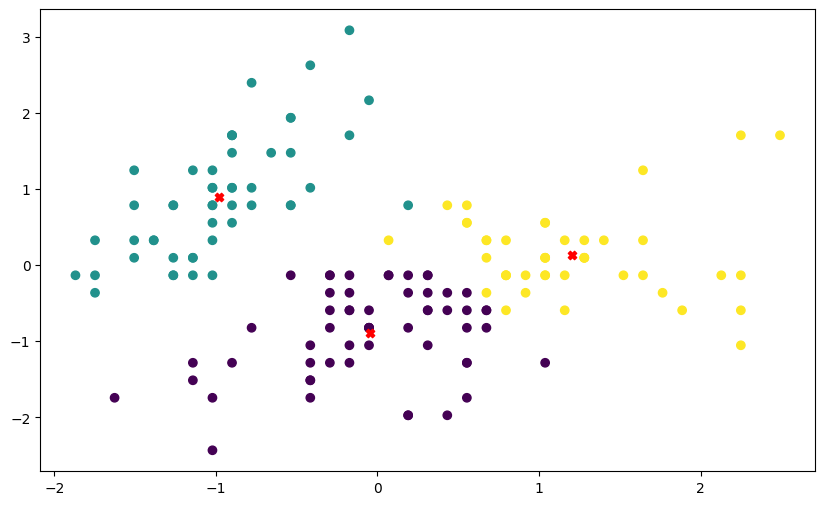

In [41]:
fig,ax = plt.subplots(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=labels)
plt.scatter(model.centroids[:,0],model.centroids[:,1],marker="X",c="Red")
plt.show()